In [37]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
import warnings

In [38]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [39]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [64]:
print(df[['MonthlyCharges', 'TotalCharges']].dtypes)

MonthlyCharges     int64
TotalCharges      object
dtype: object


In [65]:
print((df['TotalCharges'] == ' ').sum())

11


In [67]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [68]:
df['TotalCharges'] = df['TotalCharges'].astype(int)

In [69]:
X = df.drop(columns=['Churn'],axis=1)

In [70]:
X = df.drop(columns=['customerID'],axis=1)

In [71]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70,151,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84,1990,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103,7362,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29,346,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74,306,Yes


In [42]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'MultipleLines' variable:  ",end=" ")
print(df['MultipleLines'].unique())

print("Categories in'InternetService' variable:",end=" " )
print(df['InternetService'].unique())

print("Categories in 'Contract' variable:     ",end=" " )
print(df['Contract'].unique())

print("Categories in 'PaymentMethod' variable:     ",end=" " )
print(df['PaymentMethod'].unique())

Categories in 'gender' variable:      ['Female' 'Male']
Categories in 'MultipleLines' variable:   ['No phone service' 'No' 'Yes']
Categories in'InternetService' variable: ['DSL' 'Fiber optic' 'No']
Categories in 'Contract' variable:      ['Month-to-month' 'One year' 'Two year']
Categories in 'PaymentMethod' variable:      ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [43]:
y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [74]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [77]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

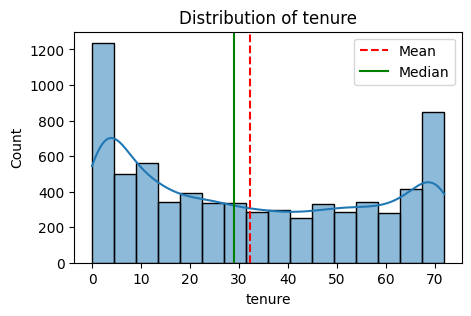

In [78]:
plot_histogram(df, "tenure")

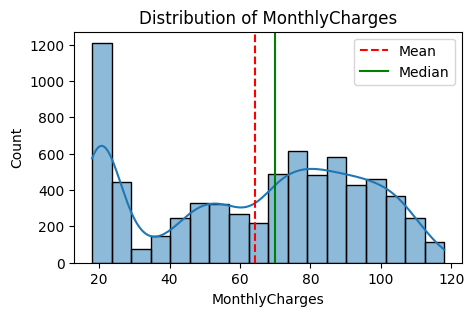

In [79]:
plot_histogram(df, "MonthlyCharges")

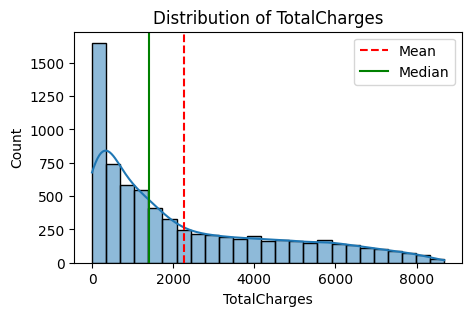

In [80]:
plot_histogram(df, "TotalCharges")

In [45]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [46]:
X = preprocessor.fit_transform(X)

In [47]:
X.shape

(7043, 13618)

In [48]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((5634, 13618), (1409, 13618))

In [49]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    "CatBoost": CatBoostClassifier(
        verbose=False,
        random_state=42
    )
}

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return accuracy, precision, recall, f1

In [51]:
model_list = []
accuracy_list = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc, train_pre, train_rec, train_f1 = evaluate_model(y_train, y_train_pred)
    test_acc, test_pre, test_rec, test_f1 = evaluate_model(y_test, y_test_pred)

    print(name)

    print("Training")
    print(f"Accuracy : {train_acc:.4f}")
    print(f"Precision: {train_pre:.4f}")
    print(f"Recall   : {train_rec:.4f}")
    print(f"F1 Score : {train_f1:.4f}")

    print("-"*40)

    print("Testing")
    print(f"Accuracy : {test_acc:.4f}")
    print(f"Precision: {test_pre:.4f}")
    print(f"Recall   : {test_rec:.4f}")
    print(f"F1 Score : {test_f1:.4f}")

    model_list.append(name)
    accuracy_list.append(test_acc)

    print("="*60)

Logistic Regression
Training
Accuracy : 0.9341
Precision: 0.9592
Recall   : 0.7854
F1 Score : 0.8637
----------------------------------------
Testing
Accuracy : 0.8254
Precision: 0.7016
Recall   : 0.5925
F1 Score : 0.6424
KNN
Training
Accuracy : 0.8374
Precision: 0.7142
Recall   : 0.6464
F1 Score : 0.6786
----------------------------------------
Testing
Accuracy : 0.7686
Precision: 0.5662
Recall   : 0.5389
F1 Score : 0.5522
Decision Tree
Training
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
----------------------------------------
Testing
Accuracy : 0.7750
Precision: 0.5915
Recall   : 0.4853
F1 Score : 0.5331
Random Forest
Training
Accuracy : 0.9998
Precision: 1.0000
Recall   : 0.9993
F1 Score : 0.9997
----------------------------------------
Testing
Accuracy : 0.7963
Precision: 0.6641
Recall   : 0.4665
F1 Score : 0.5480
AdaBoost
Training
Accuracy : 0.8007
Precision: 0.6577
Recall   : 0.5201
F1 Score : 0.5808
----------------------------------------
Testing
A

In [52]:
results = pd.DataFrame({
    "Model": model_list,
    "Accuracy": accuracy_list
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.825408
5,Gradient Boosting,0.812633
8,CatBoost,0.811923
4,AdaBoost,0.797729
6,Extra Trees,0.797019
3,Random Forest,0.796309
7,XGBoost,0.794180
2,Decision Tree,0.775018
1,KNN,0.768630


In [53]:
# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
score = accuracy_score(y_test, y_pred) * 100

print("Accuracy of the model is {:.2f}%".format(score))

Accuracy of the model is 82.54%


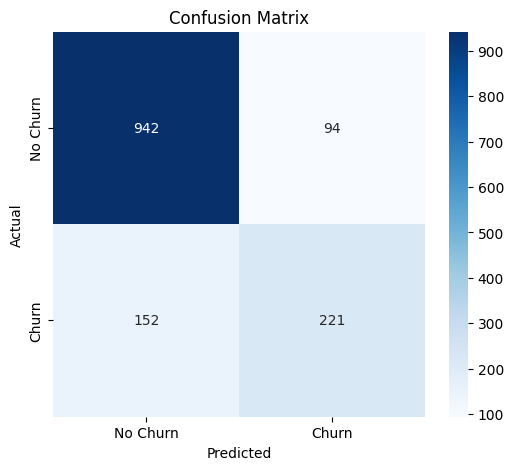

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

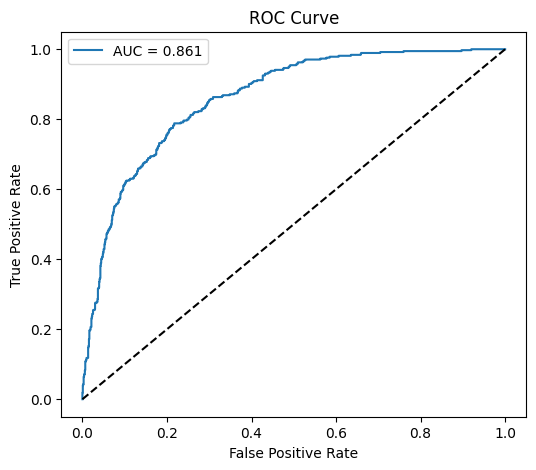

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

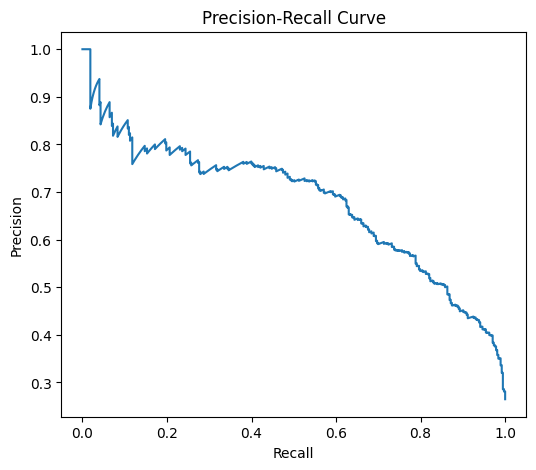

In [57]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

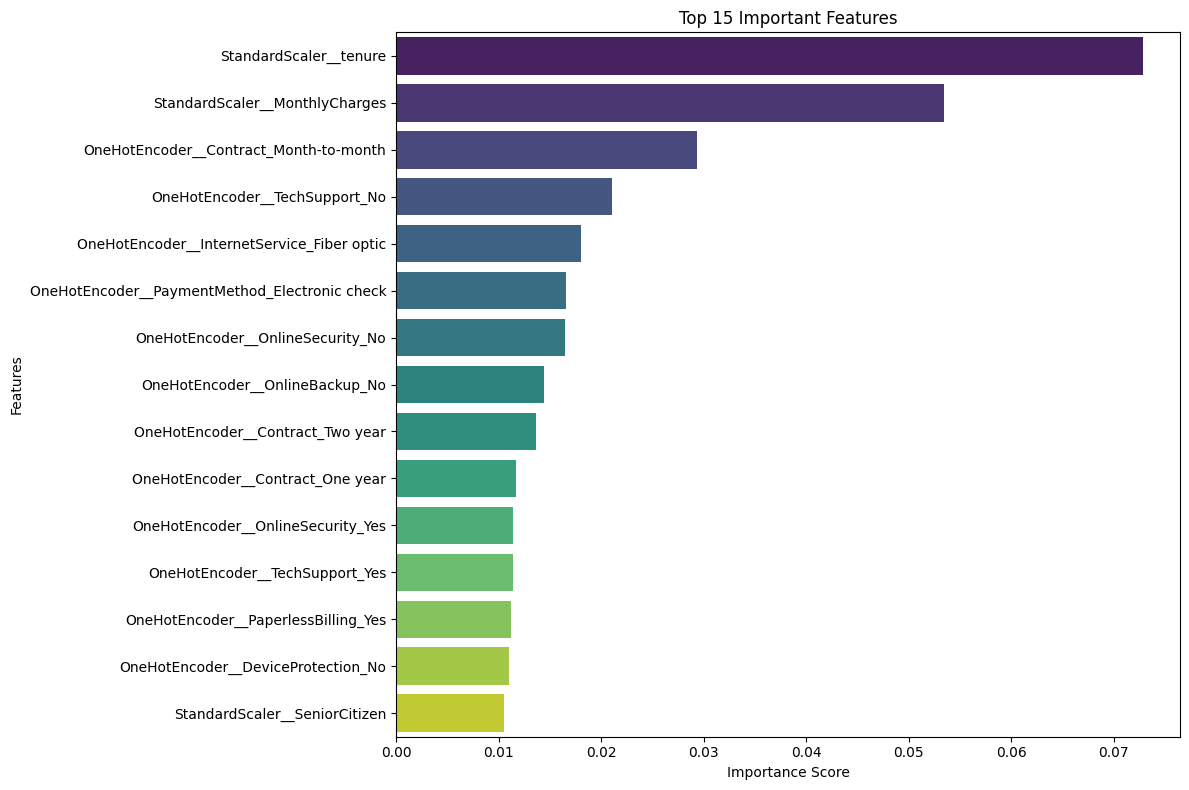

In [60]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create DataFrame
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

# Sort
importance = importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()